In [14]:
# pip install ctgan

import pandas as pd
import numpy as np
import seaborn as sns
from ctgan import CTGAN

# switch to decimal format in pandas for easier values in describe()
pd.set_option('display.float_format', '{:.2f}'.format)

# load the data
df = pd.read_csv("../houses.csv")
df = df.drop(["id", "date", "zipcode", "lat", "long"], axis=1)
df.head()

# take a copy of the dataframe for later inspections
original_df = df.copy()

## Basic CTGAN is easy to use

In [15]:
# initialize CTGAN and start training
ctgan = CTGAN()
ctgan.fit(df, epochs=100)

# by default, CTGAN requires all values in dataframe
# to be in numeric format
# however, you can place discrete variables (text categories etc.)
# into a list and pass that to CTGAN, see documentation:
# https://pypi.org/project/ctgan/


In [16]:
# get data from model
num_new_data = 10000
synthetic_df = ctgan.sample(num_new_data)

In [17]:
synthetic_df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,174833.95,3,2.01,950,8235,1.00,0,0,4,7,942,1,1939,1,1740,10046
1,1990217.12,3,3.47,4143,192948,2.00,1,4,3,10,2998,8,1987,-1,4464,40899
2,938181.29,5,1.76,2105,19188,1.00,0,4,4,9,3041,5,1986,2,4607,230185
3,393761.37,3,1.99,1175,2579,1.50,0,0,2,8,1237,-2,1909,-1,1786,10741
4,350853.50,2,1.00,965,6383,1.50,0,0,3,6,1022,4,1956,2,1481,8577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,433246.96,4,2.51,2569,3508,2.00,0,0,3,9,2449,0,2005,-2,2133,4924
9996,202612.92,4,2.50,1738,5812,1.00,0,0,3,8,2453,0,1962,0,2018,6247
9997,472732.39,4,2.49,1716,5029,1.50,0,0,5,7,1541,-3,1957,1,1789,7975
9998,571499.15,3,1.75,2299,4987,1.00,0,0,4,8,1759,-2,1994,0,2188,65068


<Axes: xlabel='price', ylabel='Count'>

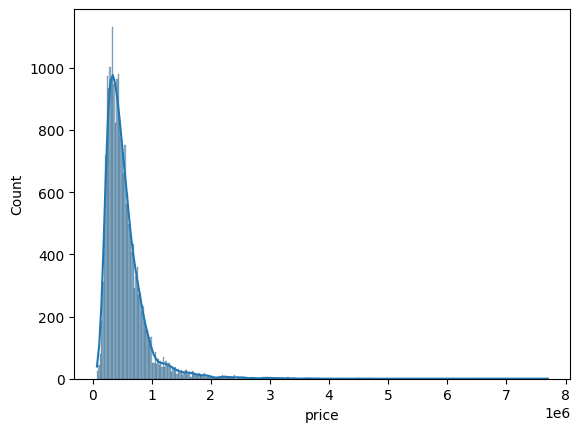

In [18]:
sns.histplot(data=df, x='price', kde=True)

In [19]:
# add the new synthetic data into the original dataframe
df = pd.concat([df, synthetic_df])

<Axes: xlabel='price', ylabel='Count'>

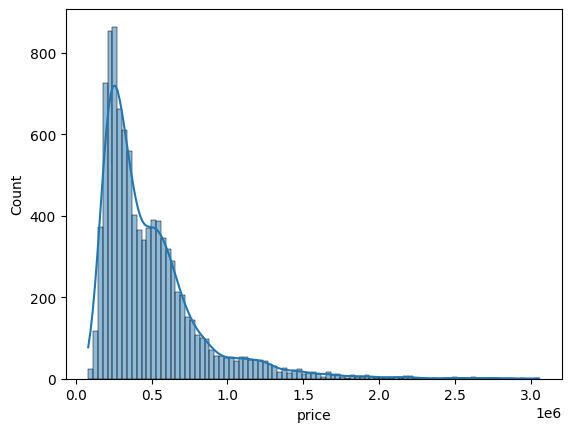

In [25]:
sns.histplot(data=synthetic_df, x='price', kde=True)


In [21]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00,31613.00
mean,523589.22,3.36,2.12,2102.03,13644.28,1.51,0.01,0.23,3.38,7.65,1751.06,295.45,1970.52,84.96,2014.21,13488.24
std,359078.10,0.93,0.76,940.93,36139.82,0.55,0.09,0.77,0.63,1.16,809.81,452.90,28.88,402.92,711.70,27342.87
min,75000.00,0.00,-0.07,290.00,-1837.00,0.99,0.00,0.00,1.00,1.00,290.00,-5.00,1897.00,-4.00,399.00,651.00
25%,299900.00,3.00,1.75,1438.00,4950.00,1.00,0.00,0.00,3.00,7.00,1148.00,0.00,1951.00,0.00,1500.00,5563.00
50%,437000.00,3.00,2.25,1930.00,7201.00,1.50,0.00,0.00,3.00,7.00,1514.00,2.00,1974.00,0.00,1860.00,7828.00
75%,630000.00,4.00,2.50,2570.00,10450.00,2.00,0.00,0.00,4.00,8.00,2215.00,567.00,1996.00,0.00,2370.00,10240.00
max,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2078.00,6210.00,871200.00


In [22]:
original_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,1986.55,12768.46
std,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,685.39,27304.18
min,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,399.00,651.00
25%,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,1490.00,5100.00
50%,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,1840.00,7620.00
75%,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,2360.00,10083.00
max,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,6210.00,871200.00


In [23]:
df.corr()['price'].sort_values(ascending=False)

price           1.00
sqft_living     0.64
grade           0.60
sqft_above      0.59
sqft_living15   0.56
bathrooms       0.50
view            0.35
bedrooms        0.33
sqft_basement   0.30
waterfront      0.21
floors          0.16
yr_renovated    0.13
sqft_lot15      0.13
sqft_lot        0.11
yr_built        0.11
condition       0.03
Name: price, dtype: float64

In [24]:
original_df.corr()['price'].sort_values(ascending=False)

price           1.00
sqft_living     0.70
grade           0.67
sqft_above      0.61
sqft_living15   0.59
bathrooms       0.53
view            0.40
sqft_basement   0.32
bedrooms        0.31
waterfront      0.27
floors          0.26
yr_renovated    0.13
sqft_lot        0.09
sqft_lot15      0.08
yr_built        0.05
condition       0.04
Name: price, dtype: float64